Title: "Milestone 5- Final Project - World Happiness Report" <br>
Class: "DSC630-T301 Predictive Analytics (2261-1) <br>
Student: "Roshan GC" <br>
Date: "11/21/2025"

# Description:

In this project, we are trying to identify which measurable factors most strongly influence national happiness using the 2019 World Happiness Report. By analyzing socioeconomic, health and social support indicators such as GDP per capita, social support, generosity, healthy life expectancy, freedom, corruption, the goal is to understand why some countries report higher levels of well being than others. By usingBy using explanatory data analysis - EDA & multiple linear regression model, we will evaluate how each factor contributes to happiness and determine which variables are the most reliable predictors of well-being across countries.


## 1. Import Libraries

In [2]:
#importing the required libraries.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

## 2. Load Dataset

In [3]:
# loading the dataset from local directory
df_2019 = pd.read_csv('/Users/roshan/Downloads/DSC630/world_happiness_data/2019.csv')
df_2019.head()

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298


# 3. Standarize Column Names
Renaming the columns so they have consistent names.

In [5]:
df = df_2019.rename(columns={
    "Country or region": "Country",
    "Score": "Happiness_Score",
    "GDP per capita": "GDP_per_capita",
    "Social support": "Social_support",
    "Healthy life expectancy": "Life_expectancy",
    "Freedom to make life choices": "Freedom",
    "Generosity": "Generosity",
    "Perceptions of corruption": "Corruption"
})

# Keepping only the relevant columns
df = df[[
    "Country",
    "Happiness_Score",
    "GDP_per_capita",
    "Social_support",
    "Life_expectancy",
    "Freedom",
    "Generosity",
    "Corruption"
]]

# Dropping any rows with missing values
df = df.dropna()

print("Number of countries in 2019 dataset:", df.shape[0])
df.head()

Number of countries in 2019 dataset: 156


,Country,Happiness_Score,GDP_per_capita,Social_support,Life_expectancy,Freedom,Generosity,Corruption
0,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298


# 4. EDA - Correlation matrix

In [12]:
corr = df[[
    "Happiness_Score",
    "GDP_per_capita",
    "Social_support",
    "Life_expectancy",
    "Freedom",
    "Generosity",
    "Corruption"
]].corr()

corr

,Happiness_Score,GDP_per_capita,Social_support,Life_expectancy,Freedom,Generosity,Corruption
Happiness_Score,1.000000,0.793883,0.777058,0.779883,0.566742,0.075824,0.385613
GDP_per_capita,0.793883,1.000000,0.754906,0.835462,0.379079,-0.079662,0.298920
Social_support,0.777058,0.754906,1.000000,0.719009,0.447333,-0.048126,0.181899
Life_expectancy,0.779883,0.835462,0.719009,1.000000,0.390395,-0.029511,0.295283
Freedom,0.566742,0.379079,0.447333,0.390395,1.000000,0.269742,0.438843
Generosity,0.075824,-0.079662,-0.048126,-0.029511,0.269742,1.000000,0.326538
Corruption,0.385613,0.298920,0.181899,0.295283,0.438843,0.326538,1.000000


# 5. Correlation Heatmap
It helps to see which variables are most strongly related to happiness.

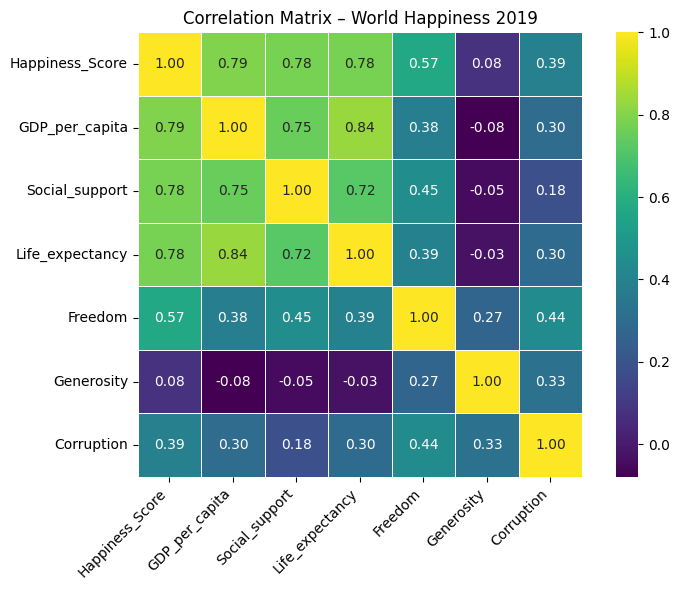

In [11]:
# Plot 1: Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    square=True,
    linewidths=0.5,
    linecolor="white"
)
plt.title("Correlation Matrix – World Happiness 2019")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 6. Scatter Plot: GDP vs Happiness
It checks if richer countries tend to be happier.

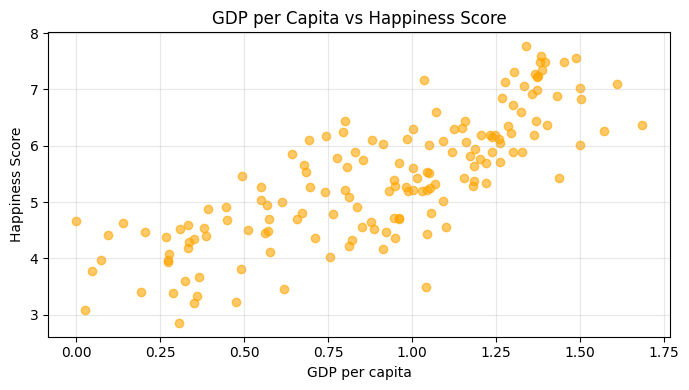

In [16]:
# Plot 2: GDP per capita vs Happiness
plt.figure(figsize=(7, 4))
plt.scatter(df["GDP_per_capita"], df["Happiness_Score"], alpha=0.6, color="orange")
plt.xlabel("GDP per capita")
plt.ylabel("Happiness Score")
plt.title("GDP per Capita vs Happiness Score")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 7. Scatter Plot : Social support vs Happiness
It shows whether countries with stronger social support tend to be happier.

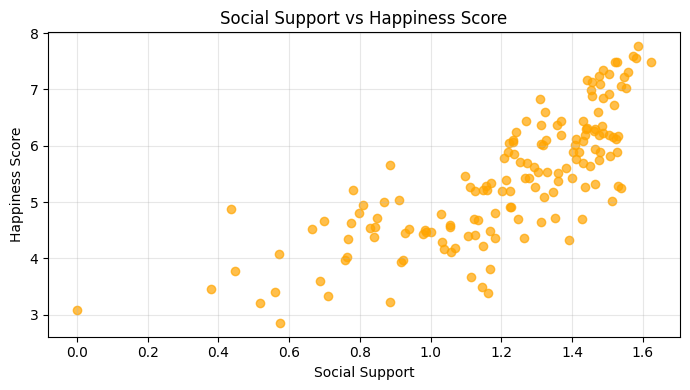

In [18]:
# Plot 3: Social support vs Happiness
plt.figure(figsize=(7, 4))
plt.scatter(df["Social_support"], df["Happiness_Score"], alpha=0.7, color="orange")
plt.xlabel("Social Support")
plt.ylabel("Happiness Score")
plt.title("Social Support vs Happiness Score")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 8. Bar Plot: Top 10 happiest Countries

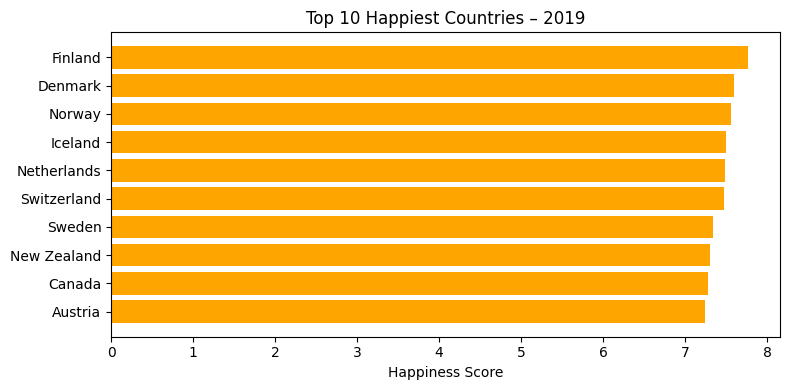

In [19]:
# Plot 4: Top 10 happiest countries for latest year
top10 = df.sort_values("Happiness_Score", ascending=False).head(10)

plt.figure(figsize=(8, 4))
plt.barh(top10["Country"], top10["Happiness_Score"], color="orange")
plt.gca().invert_yaxis()  # Highest at the top
plt.xlabel("Happiness Score")
plt.title("Top 10 Happiest Countries – 2019")
plt.tight_layout()
plt.show()

# 9. Prepare data for Regression
I will separate the target variables & other variables (y & x) and split data into training and test sets (80/20) for multiple linear regression model.


In [35]:
features = [
    "GDP_per_capita",
    "Social_support",
    "Life_expectancy",
    "Freedom",
    "Generosity",
    "Corruption"
]

X = df[features]
y = df["Happiness_Score"]

# Train-test split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# 11. Multiple Linear Regression model
I will build the final multiple linear regression model to understand how each predictor contributes to the Happiness Score.

In [34]:

X = df[[
    "GDP_per_capita",
    "Social_support",
    "Life_expectancy",
    "Freedom",
    "Generosity",
    "Corruption"
]]

y = df["Happiness_Score"].dropna().copy()

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print("=== FINAL MODEL ===")
print(f"R²:   {r2:.3f}")
print(f"RMSE: {rmse:.3f}")

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})
coef_df

=== FINAL MODEL ===
R²:   0.779
RMSE: 0.521


,Feature,Coefficient
0,GDP_per_capita,0.775372
1,Social_support,1.124192
2,Life_expectancy,1.078143
3,Freedom,1.454832
4,Generosity,0.489783
5,Corruption,0.972280
